1.분석주제
##음바페는 정말 팀에 도움이 되지 않는 선수일까?
최근 음바페에 대한 여러가지 잡음들이 많이 나오고 있는 와중 "수비를 안한다", "잘 뛰지 않는다"라는 평가가 많다.
이 분석은 음바페의 공격 데이터와 수비 데이터를 함께 확인해,이 평가가 어느정도 데이터로 설명되는지 살펴본다.
2.데이터 출처와 한계2.데이터 출처와 한계
공격 데이터로는 Understat에서 가져온 슈팅, 득점, 도움, xG, xA데이터를 사용했다.
수비 데이터로는 fotmob기준 90분당 수비적 행동, 90분당 태클, 90분당 가로채기, 90분당 볼 회수, 90분당 공격 지역 볼 회복지표를 사용했다.
다만 이 데이터에는 실제 활동량, 스프린트, 압박 강도, 수비복귀가 포함되어 있지 않기 때문에 "잘 뛰지 않는다"는 주장을 증명하기에는 한계가 있다.

In [10]:
#3 공격
#이번시즌 음바페는 31경기 출전해 25골 5 어시스트를 기록했다. 골 기록은 xG과 비교했을 때 25.53으로 골 수도 비슷하게 기록했다는 것을 볼 수 있다.
#어시스트는 xA값(7.12)보다 낮게 기록했지만 xA값을 미루어 볼때 많은 찬스들도 만들었다는 것을 볼 수 있다.
import pandas as pd

df=pd.read_csv("mbappe-data.csv",sep=";")
print(df)

   number position  apps   min  goals  assists  sp90m  kp90     xG    xA  \
0       1       FW    29  2577     25        4   4.96  2.24  25.53  7.12   
1       2      Sub     2    46      0        1   7.83  1.96   0.27  0.12   

   xG90  xA90  
0  0.89  0.25  
1  0.53  0.24  


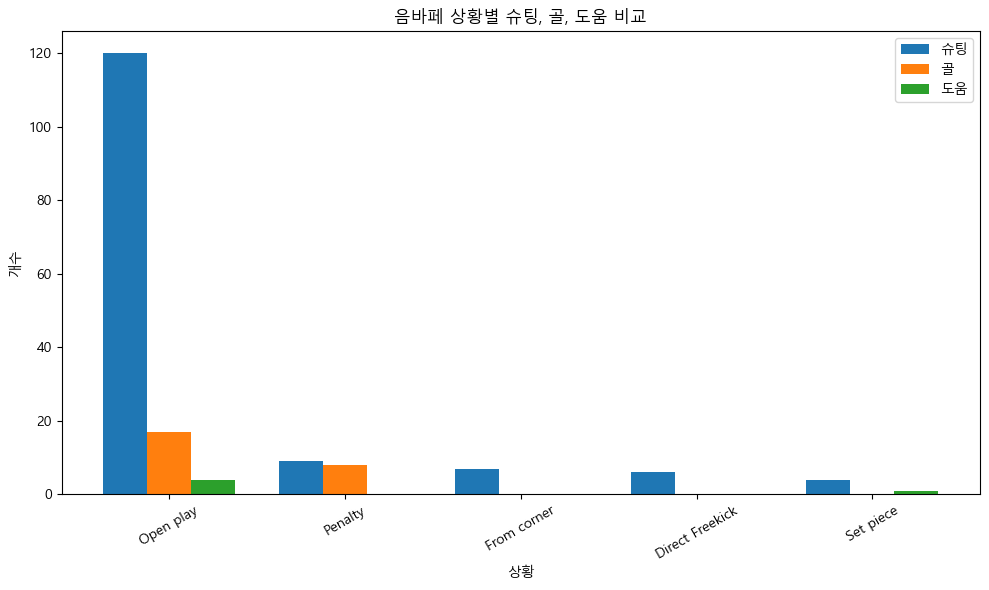

In [21]:
#3-1
#음바페는 25골중 17골을 오픈찬스에서 기록했고, 그 다음으로 페널티킥으로 8골을 넣었다.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("mbappe-data2.csv", sep=";")

x = np.arange(len(df["situation"]))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(x - width, df["shots"], width, label="슈팅")
plt.bar(x, df["goals"], width, label="골")
plt.bar(x + width, df["assists"], width, label="도움")

plt.xticks(x, df["situation"], rotation=30)
plt.title("음바페 상황별 슈팅, 골, 도움 비교")
plt.xlabel("상황")
plt.ylabel("개수")
plt.legend()
plt.tight_layout()
plt.show()

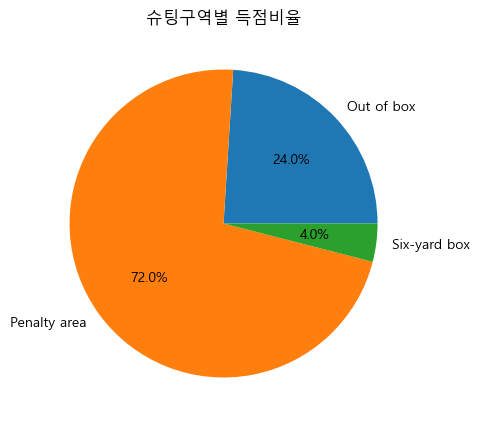

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"]="Malgun Gothic"
plt.rcParams["axes.unicode_minus"]=False

df=pd.read_csv("mbappe-data3.csv",sep=";")

plt.figure(figsize=(8,5))
plt.pie(df["goals"],labels=df["shotZones"],autopct="%1.1f%%")
plt.title("슈팅구역별 득점비율")
plt.show()
#3-2
#슈팅구역별 득점비율을 볼때 음바페는 패널티 안구역에서 많은 득점을 만들었다.
#박스 밖에서도 득점을 기록했지만, 보통은 박스 안쪽에서 득점을 했다 볼 수 있다.
#이를 볼때 음바페는 득점 가능성이 높은 지역에서 마무리하는 비중이 큰 선수로 볼 수 있다.

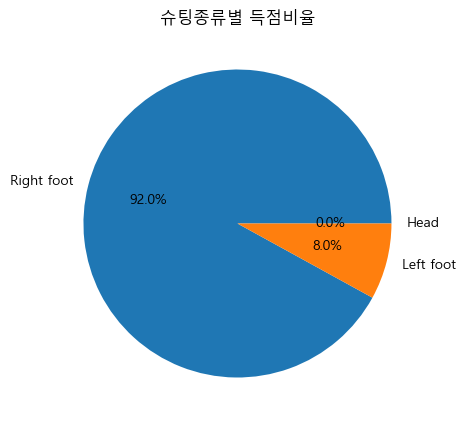

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"]="Malgun Gothic"
plt.rcParams["axes.unicode_minus"]=False

df=pd.read_csv("mbappe-data4.csv",sep=";")

plt.figure(figsize=(8,5))
plt.pie(df["goals"],labels=df["shotTypes"],autopct="%1.1f%%")
plt.title("슈팅종류별 득점비율")
plt.show()
#3-3
#음바페는 슈팅종류별 득점비율중 오른발 득점 비율이 92퍼로 주로 오른발로 득점한다는것을 알 수 있다.

            player  defensive_actions  defensive_actions_per90
2          Rodrygo                 20                      2.7
0   Gonzalo Garcia                 23                      2.2
3  Vinicius Junior                 32                      1.0
1    Kylian Mbappe                  6                      0.2


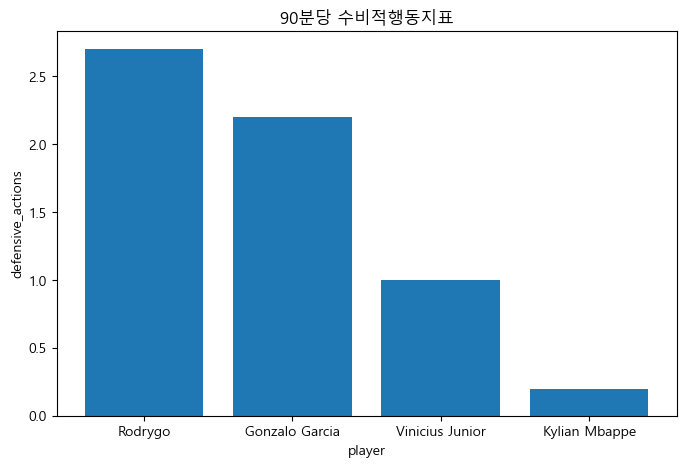

In [5]:
#4(수비지표)
#4-1
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"]="Malgun Gothic"
plt.rcParams["axes.unicode_minus"]=False

df=pd.read_csv("real_madrid_attackers_defensive_actions_per90.csv")
defensive_sorted= df.sort_values("defensive_actions_per90", ascending=False)
print(defensive_sorted[["player","defensive_actions","defensive_actions_per90"]])

plt.figure(figsize=(8,5))
plt.bar(defensive_sorted["player"],defensive_sorted["defensive_actions_per90"])
plt.title("90분당 수비적행동지표")
plt.xlabel("player")
plt.ylabel("defensive_actions")
plt.show()
#음바페는 수비적행동과 90분당 수비적행동 지표가 4명의 공격수 중 가장 낮은 수치를 기록하고 있다.

            player  tackles  tackles_per90
2          Rodrygo       13            1.7
0   Gonzalo Garcia       11            1.0
3  Vinicius Junior       29            0.9
1    Kylian Mbappe        4            0.1


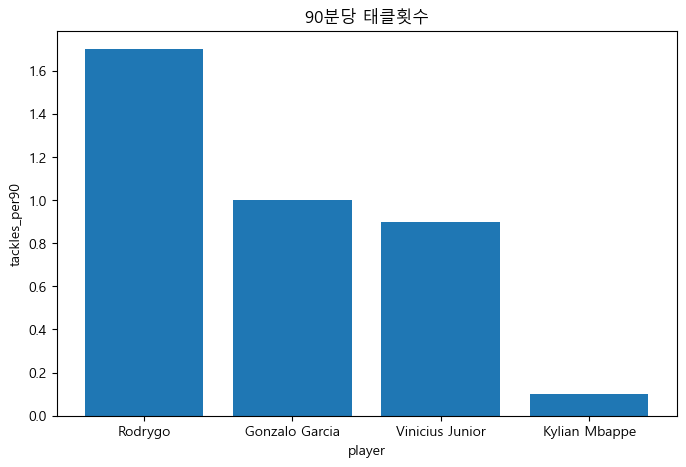

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"]="Malgun Gothic"
plt.rcParams["axes.unicode_minus"]=False

df=pd.read_csv("real_madrid_attackers_tackles_per90.csv")

#print(df)

tackles_per90_sorted=df.sort_values("tackles_per90",ascending=False)
print(tackles_per90_sorted[["player","tackles","tackles_per90"]])

plt.figure(figsize=(8,5))
plt.bar(tackles_per90_sorted["player"],tackles_per90_sorted["tackles_per90"])
plt.title("90분당 태클횟수")
plt.xlabel("player")
plt.ylabel("tackles_per90")
plt.show()
#4-2 음바페는 태클횟수 90분당 태클횟수도 4명의 공격수들중 가장 낮은 수치를 기록하고 있다.

            player  interceptions  interceptions_per90
2          Rodrygo              3                  0.4
0   Gonzalo Garcia              3                  0.3
1    Kylian Mbappe              2                  0.1
3  Vinicius Junior              2                  0.1


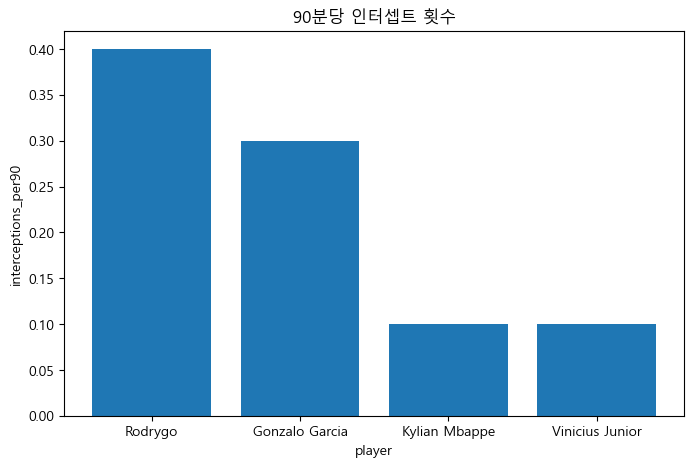

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"]="Malgun Gothic"
plt.rcParams["axes.unicode_minus"]=False

df=pd.read_csv("real_madrid_attackers_interceptions_per90.csv")

interceptions_sorted=df.sort_values("interceptions_per90", ascending=False)
print(interceptions_sorted[["player","interceptions","interceptions_per90"]])

plt.figure(figsize=(8,5))
plt.bar(interceptions_sorted["player"],interceptions_sorted["interceptions_per90"])
plt.title("90분당 인터셉트 횟수")
plt.xlabel("player")
plt.ylabel("interceptions_per90")
plt.show()
#인터셉트, 90분당 인터셉트도 4명의 공격수들중 비니시우스와 똑같은 수치를 기록하며 팀내에서 가장 적은 인터셉트 수치를 기록하고 있다.

            player  ball_recoveries  ball_recoveries_per90
2          Rodrygo               38                    5.1
3  Vinicius Junior               88                    2.8
0   Gonzalo Garcia               23                    2.2
1    Kylian Mbappe               44                    1.5


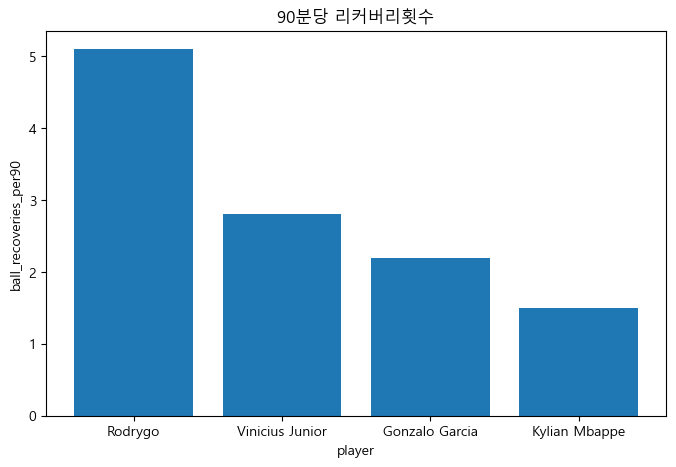

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"]="Malgun Gothic"
plt.rcParams["axes.unicode_minus"]=False

df=pd.read_csv("real_madrid_attackers_ball_recoveries_per90.csv")

#print(df)

ball_recoveris_sorted=df.sort_values("ball_recoveries_per90", ascending=False)
print(ball_recoveris_sorted[["player","ball_recoveries","ball_recoveries_per90"]])

plt.figure(figsize=(8,5))
plt.bar(ball_recoveris_sorted["player"],ball_recoveris_sorted["ball_recoveries_per90"])
plt.title("90분당 리커버리횟수")
plt.xlabel("player")
plt.ylabel("ball_recoveries_per90")
plt.show()
#리커버리 횟수도 음바페가 가장낮은 수치를 기록하고 있다.

            player  value_per90
2          Rodrygo          1.1
0   Gonzalo Garcia          0.9
1    Kylian Mbappe          0.7
3  Vinicius Junior          0.7


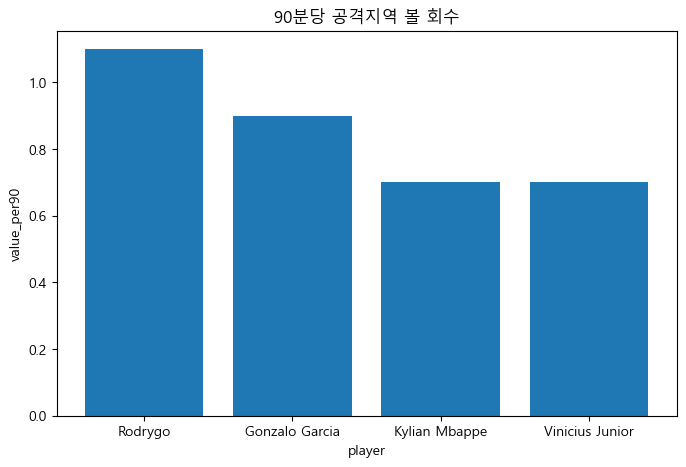

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"]="Malgun Gothic"
plt.rcParams["axes.unicode_minus"]=False

df=pd.read_csv("real_madrid_attackers_final_third_recoveries_per90.csv")
#print(df)
final_third_recoveries_sorted=df.sort_values("value_per90",ascending=False)
print(final_third_recoveries_sorted[["player","value_per90"]])

plt.figure(figsize=(8,5))
plt.bar(final_third_recoveries_sorted["player"],final_third_recoveries_sorted["value_per90"])
plt.title("90분당 공격지역 볼 회수")
plt.xlabel("player")
plt.ylabel("value_per90")
plt.show()
#공격지역 볼 회수 부분에서도 음바페는 비니시우스와 같은 기록(0.7)을 기록하며 팀내에서 가장 적은 수치를 기록하고 있다.

In [ ]:
#5
#Understat공격 데이터를 바탕으로 음바페는 공격 스텟을 많이 쌓았다. 패널티 박스 안쪽에서 뿐만 아니라 패널티 밖에서도 많은 슈팅과
#골을 만든것으로 볼때 공격상황에서의 음바페는 확실히 좋은 모습을 보여준다고 볼 수 있다.
#하지만 fotmob수비 데이터를 바탕으로 볼 때 음바페가 레알 마드리드 공격진 내부에서 수비 관여도가 낮은 것을 볼 수 있다.
#특히 90분당 수비적행동, 태클, 볼 회수 지표에서 음바페는 비교 선수들보다 낮은 수치를 기록했다.

#6
#음바페는 이번시즌 공격수로써 공격 생산성 측면에서는 많이 기여한 선수중 한명이다.
#하지만 수비적인 지표를 따르면, 레알 마드리드 공격진에서 수비 관여도가 가장 낮은 것으로 나타났다.
#"팀에 도움이 되지않는다"라는 평가는 과할 순 있지만, 수비적인 상황에서 관여가 적은 공격수라는 평가는 일부 데이터로 평가받을 수 있을거같다
#다만 실제 활동량과 스프린트 횟수, 압박강도, 수비 복귀 데이터가 포함되어 있지 않기 때문에
#이 결과는 공개 지표를 활용한 1차 분석으로 보는것이 좋다.